In [ ]:
import os
import zipfile
import cv2
import numpy as np

In [ ]:
zip_path = "/content/drive/MyDrive/ECG_images_classfication.zip"
extract_path = "/mnt/data/ecg_raw"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: /mnt/data/ecg_raw


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def remove_header_footer_only(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    h, w, _ = img.shape

    # ==========================
    # REMOVE ONLY TOP & BOTTOM
    # ==========================
    top_cut = int(0.17 * h)      # removes ECG REPORT section
    bottom_cut = int(0.94 * h)   # removes footer text

    trimmed = img[top_cut:bottom_cut, :]  # keep full width

    return trimmed


In [ ]:
input_dir = "/mnt/data/ecg_raw"
output_dir = "/mnt/data/ecg_trimmed"

os.makedirs(output_dir, exist_ok=True)

for cls in os.listdir(input_dir):
    cls_input = os.path.join(input_dir, cls)
    cls_output = os.path.join(output_dir, cls)

    if not os.path.isdir(cls_input):
        continue

    os.makedirs(cls_output, exist_ok=True)

    for img_name in os.listdir(cls_input):
        img_path = os.path.join(cls_input, img_name)

        trimmed_img = remove_header_footer_only(img_path)

        if trimmed_img is None:
            continue

        cv2.imwrite(
            os.path.join(cls_output, img_name),
            trimmed_img
        )

    print(f"Processed: {cls}")


Processed: ECG Images of Patient that have abnormal heart beats (548)
Processed: ECG Images of COVID-19 Patients (250)
Processed: ECG Images of Myocardial Infarction Patients (77)
Processed: Normal Person ECG Images (859)
Processed: ECG Images of Patient that have History of MI (203)


Text(0.5, 1.0, 'Header & Footer Removed – ECG Box Preserved')

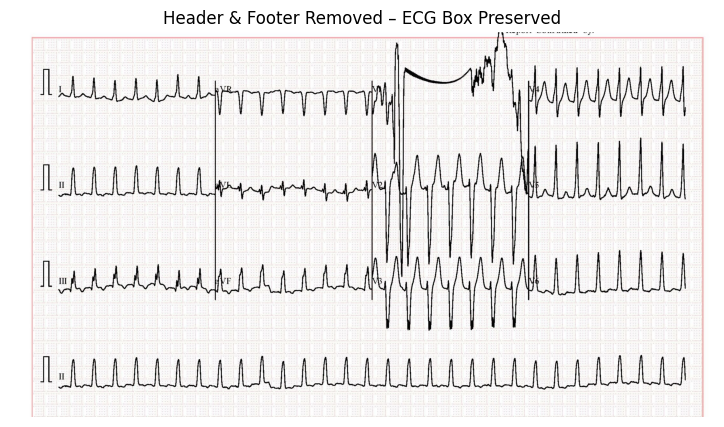

In [ ]:
import matplotlib.pyplot as plt

sample_class = os.listdir(output_dir)[0]
sample_img = os.listdir(os.path.join(output_dir, sample_class))[0]

img = cv2.imread(os.path.join(output_dir, sample_class, sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))
plt.imshow(img)
plt.axis("off")
plt.title("Header & Footer Removed – ECG Box Preserved")


In [ ]:
import os

processed_path = "/mnt/data/ecg_trimmed"
total = 0
for root, dirs, files in os.walk(processed_path):
    print(root, "->", len(files), "files")
    total += len(files)

print("Total images:", total)


/mnt/data/ecg_trimmed -> 0 files
/mnt/data/ecg_trimmed/ECG Images of Patient that have abnormal heart beats (548) -> 546 files
/mnt/data/ecg_trimmed/ECG Images of COVID-19 Patients (250) -> 250 files
/mnt/data/ecg_trimmed/ECG Images of Myocardial Infarction Patients (77) -> 74 files
/mnt/data/ecg_trimmed/Normal Person ECG Images (859) -> 859 files
/mnt/data/ecg_trimmed/ECG Images of Patient that have History of MI (203) -> 203 files
Total images: 1932


In [ ]:
import zipfile
import os

zip_path = "/content/ecg_trimmed_dataset.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(processed_path):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, processed_path)
            zipf.write(file_path, arcname)

print("ZIP created at:", zip_path)


ZIP created at: /content/ecg_trimmed_dataset.zip


In [2]:
pip install torch torchvision scikit-learn matplotlib numpy pillow tqdm

In [3]:
import os
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 2
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # ECG images often grayscale
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [6]:
import os
import shutil
import random
# ================= CONFIG =================
SOURCE_DIR = "/content/drive/MyDrive/ECG_IMAGES_1"     # your original dataset
DEST_DIR = "dataset"          # new dataset directory

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42
random.seed(SEED)

# =========================================

classes = os.listdir(SOURCE_DIR)

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST_DIR, split, cls), exist_ok=True)

for cls in classes:
    class_path = os.path.join(SOURCE_DIR, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "test", cls, img)
        )
print("✅ Dataset split completed successfully!")

✅ Dataset split completed successfully!


In [7]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

In [8]:
from collections import Counter

def count_images(path):
    counts = {}
    for cls in os.listdir(path):
        counts[cls] = len(os.listdir(os.path.join(path, cls)))
    return counts
print("Train:", count_images("/content/dataset/train"))
print("Val:", count_images("/content/dataset/val"))
print("Test:", count_images("/content/dataset/test"))

Train: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382}
Val: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81}
Test: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83}


handling class imbalance


In [9]:
class_counts = np.bincount(train_dataset.targets)
class_weights = 1. / class_counts
sample_weights = class_weights[train_dataset.targets]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
import os

def count_images_per_class(dataset_path):
    class_counts = {}
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len([
                img for img in os.listdir(cls_path)
                if img.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
    return class_counts

print("Train set:", count_images_per_class("dataset/train"))
print("Validation set:", count_images_per_class("dataset/val"))
print("Test set:", count_images_per_class("dataset/test"))

Train set: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382}
Validation set: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81}
Test set: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83}


In [12]:
import numpy as np
from collections import Counter

targets = train_dataset.targets  # class labels
class_counts = Counter(targets)

print("Original class distribution:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} images")

# Effective sampling per epoch
sampled_indices = list(train_loader.sampler)
sampled_targets = [targets[i] for i in sampled_indices]
sampled_counts = Counter(sampled_targets)
print("\nEffective distribution per epoch (after imbalance handling):")
for cls, count in sampled_counts.items():
    print(f"Class {cls}: {count} samples")

Original class distribution:
Class 0: 382 images
Class 1: 601 images

Effective distribution per epoch (after imbalance handling):
Class 1: 503 samples
Class 0: 480 samples


In [13]:
import os
import shutil
import random
from tqdm import tqdm

# ==============================
# Paths
# ==============================

source_dir = "/content/drive/MyDrive/ECG_IMAGES_1"   # your dataset
output_dir = "/content/dataset1"      # new split dataset

# Create folders
for split in ["train", "val", "test"]:
    for cls in os.listdir(source_dir):
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)


# ==============================
# Split Function
# ==============================

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in os.listdir(source_dir):

    class_path = os.path.join(source_dir, cls)
    images = os.listdir(class_path)

    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = int((train_ratio + val_ratio) * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]


    # Copy files
    for img in tqdm(train_imgs, desc=f"Train {cls}"):
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, "train", cls, img))

    for img in tqdm(val_imgs, desc=f"Val {cls}"):
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, "val", cls, img))

    for img in tqdm(test_imgs, desc=f"Test {cls}"):
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, "test", cls, img))


print("✅ Dataset split completed!")

Test Normal Person ECG Images (859): 100%|██████████| 129/129 [00:02<00:00, 48.64it/s]
Train ECG Images of Patient that have abnormal heart beats (548): 100%|██████████| 382/382 [00:08<00:00, 46.20it/s]
Val ECG Images of Patient that have abnormal heart beats (548): 100%|██████████| 82/82 [00:02<00:00, 40.25it/s]
Test ECG Images of Patient that have abnormal heart beats (548): 100%|██████████| 82/82 [00:01<00:00, 55.11it/s]

✅ Dataset split completed!


In [14]:
from collections import Counter

def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        counts[cls] = len(os.listdir(os.path.join(folder, cls)))
    return counts

print("Train:", count_images("/content/dataset1/train"))
print("Val:", count_images("/content/dataset1/val"))
print("Test:", count_images("/content/dataset1/test"))

Train: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382}
Val: {'Normal Person ECG Images (859)': 129, 'ECG Images of Patient that have abnormal heart beats (548)': 82}
Test: {'Normal Person ECG Images (859)': 129, 'ECG Images of Patient that have abnormal heart beats (548)': 82}


Device: cuda
Class distribution: [382 601]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


Epoch [1/40] Loss: 0.4515
Epoch [2/40] Loss: 0.3820
Epoch [3/40] Loss: 0.3682
Epoch [4/40] Loss: 0.3616
Epoch [5/40] Loss: 0.3826
Epoch [6/40] Loss: 0.3096
Epoch [7/40] Loss: 0.3182
Epoch [8/40] Loss: 0.3382
Epoch [9/40] Loss: 0.3159
Epoch [10/40] Loss: 0.3156
Epoch [11/40] Loss: 0.2924
Epoch [12/40] Loss: 0.2978
Epoch [13/40] Loss: 0.2826
Epoch [14/40] Loss: 0.2755
Epoch [15/40] Loss: 0.2526
Epoch [16/40] Loss: 0.3002
Epoch [17/40] Loss: 0.2777
Epoch [18/40] Loss: 0.2821
Epoch [19/40] Loss: 0.2436
Epoch [20/40] Loss: 0.2795
Epoch [21/40] Loss: 0.2559
Epoch [22/40] Loss: 0.2336
Epoch [23/40] Loss: 0.2603
Epoch [24/40] Loss: 0.2919
Epoch [25/40] Loss: 0.3079
Epoch [26/40] Loss: 0.2409
Epoch [27/40] Loss: 0.2674
Epoch [28/40] Loss: 0.2542
Epoch [29/40] Loss: 0.2569
Epoch [30/40] Loss: 0.2303
Epoch [31/40] Loss: 0.2818
Epoch [32/40] Loss: 0.2113
Epoch [33/40] Loss: 0.2338
Epoch [34/40] Loss: 0.2427
Epoch [35/40] Loss: 0.2429
Epoch [36/40] Loss: 0.2495
Epoch [37/40] Loss: 0.2414
Epoch [38/

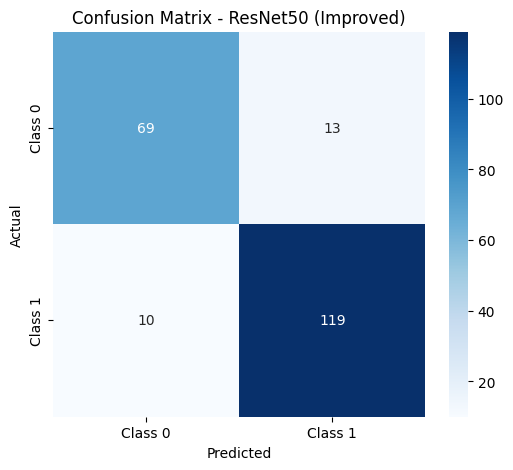

In [15]:
# ==============================
# 1 Imports
# ==============================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ==============================
# 2 Data Augmentation (Improved)
# ==============================

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, shear=10, scale=(0.9,1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


# ==============================
# 3 Load Dataset
# ==============================

train_dir = "/content/dataset1/train"
val_dir   = "/content/dataset1/val"
test_dir  = "/content/dataset1/test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_transform)


# ==============================
# 4 Handle Class Imbalance (BEST METHOD)
# ==============================

targets = train_dataset.targets
class_counts = np.bincount(targets)

print("Class distribution:", class_counts)

weights = 1. / class_counts
samples_weight = np.array([weights[t] for t in targets])

sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)


# ==============================
# 5 Load ResNet50
# ==============================

model = models.resnet50(pretrained=True)

# Freeze early layers, unfreeze last block
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Replace FC layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)


# ==============================
# 6 Loss, Optimizer, Scheduler
# ==============================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.3)


# ==============================
# 7 Training Function
# ==============================

def train_model(model, train_loader, val_loader, epochs=40):

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")


# ==============================
# 8 Train Model
# ==============================

train_model(model, train_loader, val_loader, epochs=40)


# ==============================
# 9 Evaluation Function
# ==============================

def evaluate(model, loader):

    model.eval()

    preds = []
    labels_list = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            labels_list.extend(labels.numpy())

    return labels_list, preds


# ==============================
# 10 Test Evaluation
# ==============================

labels, preds = evaluate(model, test_loader)

print("\nClassification Report:\n")
print(classification_report(labels, preds))

acc = accuracy_score(labels, preds)
print("Test Accuracy:", acc)


# ==============================
# 11 Confusion Matrix (Image)
# ==============================

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Class 0","Class 1"],
            yticklabels=["Class 0","Class 1"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50 (Improved)")

plt.show()

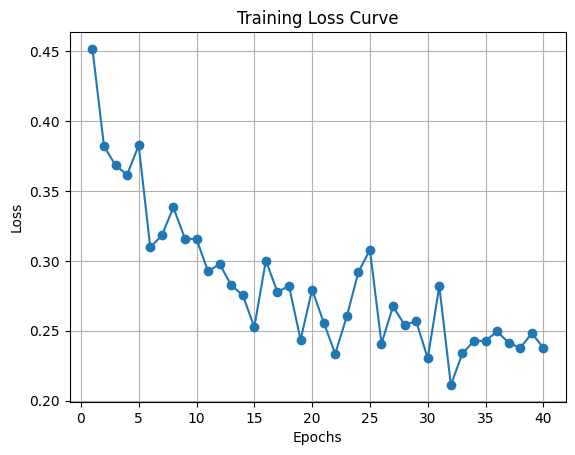

In [16]:
import matplotlib.pyplot as plt

# Updated training losses
train_losses = [
    0.4515, 0.3820, 0.3682, 0.3616, 0.3826,
    0.3096, 0.3182, 0.3382, 0.3159, 0.3156,
    0.2924, 0.2978, 0.2826, 0.2755, 0.2526,
    0.3002, 0.2777, 0.2821, 0.2436, 0.2795,
    0.2559, 0.2336, 0.2603, 0.2919, 0.3079,
    0.2409, 0.2674, 0.2542, 0.2569, 0.2303,
    0.2818, 0.2113, 0.2338, 0.2427, 0.2429,
    0.2495, 0.2414, 0.2377, 0.2482, 0.2378
]

# Epochs
epochs = list(range(1, len(train_losses) + 1))

# Plot
plt.figure()

plt.plot(epochs, train_losses, marker='o')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid()

plt.show()